# Sentiment Drift Paper — GPU Track
### Run this when Kaggle GPU quota resets. Companion to `sentiment_cpu_track.ipynb`.

---

**This is the GPU-dependent half of the pipeline.** Run `sentiment_cpu_track.ipynb` FIRST —
it caches HC3, Yelp, and the HC3 opinion-subset as parquet files so this notebook doesn't
spend GPU time on downloads. This notebook covers everything that genuinely needs a GPU:

- Phase 2: Qwen3-4B-Instruct-2507 + Gemma-3-4b-it paraphrase generation (the core novel drift experiment)
- Phase 3 (Bucket C only): AI-text ECE, completing the stratified-ECE table started in the CPU notebook
- Phase 3.5: Semantic entropy vs MC-Dropout comparison, both model families
- Phase 4: The uncertainty wrapper + abstention ablation
- Phase 5 (optional): Explanation generation

---

**KAGGLE UNATTENDED-EXECUTION SETUP — read before running:**

1. **Attach the CPU notebook's output as a data source.** On Kaggle: open this notebook →
   "Add Data" → "Notebook Output Files" → select your committed `sentiment_cpu_track` run.
   This mounts its parquet files at `/kaggle/input/<cpu-notebook-name>/results/phase2_data_prep/`
   — no re-downloading HC3/Yelp, saving ~10-15 minutes of GPU-billed time at the start.
2. **Set Accelerator: GPU T4 x2 (or whatever Kaggle offers you) in notebook settings.**
3. **Enable Internet** (needed for model downloads from Hugging Face on first run).
4. **Use "Save & Run All (Commit)"** — this is what gives you true unattended execution.
   Kaggle keeps committed-run sessions executing in the background; you do not need to keep
   the browser tab open or poke the notebook, unlike Colab free tier.
5. **Session limits to plan around:** 12-hour max execution time per session, ~30 hours/week
   total GPU quota. Budget: Phase 2 generation (~2-3 hrs for both models on 5k examples) +
   Phase 3.5 sampling (~1-1.5 hrs) + Phase 4/5 (~30-45 min) comfortably fits in one 12-hour
   commit, with hours to spare for re-runs if something fails partway.
6. **Every long-running cell below checkpoints to disk every 200 examples.** If a session
   does die mid-run (queue timeout, transient Kaggle issue), re-running the same cell resumes
   from the last checkpoint instead of restarting — this is the main defense against losing
   GPU-hour budget to an interrupted run.

---

**Environment target:**
- Python 3.10+
- Kaggle Notebook, GPU accelerator (T4 or P100), Internet enabled
- Estimated total compute: ~4-5 GPU hours across all phases (two free LLMs instead of one
  roughly doubles the original 2-3 hour estimate — budget accordingly within your weekly quota)


## Path Configuration -- edit this cell ONLY, run it FIRST

Every other cell in this notebook reads `BASE_DIR` (and `DIRS`/`CACHE_DIR` derived from it)
from this one place. If you ever need to run this somewhere other than Kaggle/Colab default
paths -- a different Kaggle dataset-output mount, a local machine, a different Colab path --
change it HERE and nowhere else. No other cell should hardcode `/kaggle/working` or `/content`
directly.


In [1]:
# --- PATH CONFIG: the single source of truth for where this notebook reads/writes ---
# Edit BASE_DIR_OVERRIDE below if you need a non-default location. Leave it as None to use
# the automatic Kaggle/Colab detection.
import os

BASE_DIR_OVERRIDE = None  # e.g. "/kaggle/working/my_custom_results" -- leave None for auto-detect

IS_KAGGLE = os.path.exists("/kaggle/working")

if BASE_DIR_OVERRIDE is not None:
    BASE_DIR = BASE_DIR_OVERRIDE
elif IS_KAGGLE:
    BASE_DIR = "/kaggle/working/results"
else:
    BASE_DIR = "/content/results"

print(f"Platform detected: {'Kaggle' if IS_KAGGLE else 'Colab/other'}")
print(f"BASE_DIR set to: {BASE_DIR}")
print("Every other cell in this notebook reads BASE_DIR/IS_KAGGLE from this cell -- nothing else sets them.")


Platform detected: Kaggle
BASE_DIR set to: /kaggle/working/results
Every other cell in this notebook reads BASE_DIR/IS_KAGGLE from this cell -- nothing else sets them.


## Phase 0 — Environment Setup & Reproducibility Scaffolding

Pinned versions, fixed seeds, deterministic settings. **Do not skip this cell.**


In [2]:
# --- Phase 0.1: Install dependencies (no pinned versions -- let pip resolve) ---
# Versions are recorded at the end of the notebook by the version-snapshot cell.
# Do not pin versions here -- Kaggle's base image has pre-installed packages and
# pinning causes resolver conflicts. Let pip pick compatible versions.

#!pip install -q --upgrade transformers datasets accelerate
#!pip install -q sentencepiece huggingface_hub scikit-learn scipy pandas matplotlib
!pip install -q vaderSentiment 
!pip install -q bert-score
!pip install -q bitsandbytes

print("Installs complete.")


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 126.0/126.0 kB 3.1 MB/s eta 0:00:0000:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.1/61.1 kB 2.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 40.9/40.9 MB 48.0 MB/s eta 0:00:00:00:0100:01
Installs complete.


In [3]:
# --- Phase 0.1b: Kernel restart cell (disabled by default) ---
# Uncomment and run this cell ONLY if you hit a stale-import error after install.
# In a fresh Kaggle "Save & Run All" container this is never needed.
# After uncommenting and running: wait for kernel to restart, then run from Phase 0.1c.

# import os
# print("Restarting kernel to clear stale imports...")
# os.kill(os.getpid(), 9)

print("Kernel restart cell is commented out (not needed for fresh containers).")


Kernel restart cell is commented out (not needed for fresh containers).


In [4]:
# --- Phase 0.1c: Smoke test ---
import transformers
print(f"transformers version: {transformers.__version__}")

from transformers import AutoTokenizer
_tok = AutoTokenizer.from_pretrained("bert-base-uncased")
print("Smoke test PASSED: AutoTokenizer loaded cleanly.")
del _tok


transformers version: 5.0.0


config.json:   0%|          | 0.00/570 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

Smoke test PASSED: AutoTokenizer loaded cleanly.


In [5]:
# --- Phase 0.2: Fixed seeds + deterministic flags ---
import random
import numpy as np
import torch
import os

SEED = 42

def set_all_seeds(seed=SEED):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    os.environ["PYTHONHASHSEED"] = str(seed)
    # Determinism flags — these can slow training slightly but are required
    # for reproducible numbers across runs/hardware.
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

set_all_seeds(SEED)
print(f"All seeds fixed to {SEED}. CUDA available: {torch.cuda.is_available()}")


All seeds fixed to 42. CUDA available: True


In [6]:
# --- TORCHAUDIO BLOCKER (must run before any transformers import) ---
# transformers.loss.loss_rnnt does: if is_torchaudio_available(): import torchaudio
# On Kaggle GPU, torchaudio crashes (CUDA 13.0 vs 12.8 mismatch) during its own __init__,
# propagating as ModuleNotFoundError for pipeline. Fix: register None in sys.modules
# so is_torchaudio_available() returns False and the import is never attempted.
import sys
for _m in list(sys.modules.keys()):
    if "torchaudio" in _m:
        sys.modules[_m] = None  # type: ignore
sys.modules["torchaudio"] = None  # type: ignore
sys.modules["torchaudio._extension"] = None  # type: ignore
sys.modules["torchaudio.lib"] = None  # type: ignore
print("torchaudio blocked in sys.modules. Safe to import transformers.")


torchaudio blocked in sys.modules. Safe to import transformers.


In [7]:
# --- Phase 0.3: Directory structure + locate CPU-notebook cached data ---
# NOTE: IS_KAGGLE and BASE_DIR are already set by the "Path Configuration" cell at the very
# top of this notebook -- this cell only builds DIRS and locates the CPU notebook's cache.
import glob

DIRS = {
    "data":      f"{BASE_DIR}/data",
    "phase2":    f"{BASE_DIR}/phase2_ai_drift",
    "phase3":    f"{BASE_DIR}/phase3_calibration",
    "phase35":   f"{BASE_DIR}/phase3_5_semantic_uncertainty",
    "phase4":    f"{BASE_DIR}/phase4_wrapper",
    "phase5":    f"{BASE_DIR}/phase5_explanations",
    "manifest":  f"{BASE_DIR}/manifest",
}
for d in DIRS.values():
    os.makedirs(d, exist_ok=True)

# Locate the CPU notebook's cached parquet files, if attached as a Kaggle data source.
# Kaggle mounts attached notebook outputs under /kaggle/input/<notebook-slug>/...
CACHE_CANDIDATES = glob.glob("/kaggle/input/notebooks/shresthshroff/sentiment-cpu/results/phase2_data_prep") if IS_KAGGLE else []
CACHE_DIR = CACHE_CANDIDATES[0] if CACHE_CANDIDATES else None

print("Using BASE_DIR from the Path Configuration cell:", BASE_DIR)
print("Directory structure created under", BASE_DIR)
for k, v in DIRS.items():
    print(f"  {k:10s} -> {v}")

if CACHE_DIR:
    print(f"\nFound CPU-notebook cache at: {CACHE_DIR}")
    print("Cached files:", os.listdir(CACHE_DIR))
else:
    print("\nNo CPU-notebook cache found. Either you're on Colab (expected -- this path doesn't")
    print("apply there), or you forgot to attach the CPU notebook's output as a Kaggle data")
    print("source. Phase 2 below will fall back to downloading HC3/Yelp directly if CACHE_DIR is None.")


Using BASE_DIR from the Path Configuration cell: /kaggle/working/results
Directory structure created under /kaggle/working/results
  data       -> /kaggle/working/results/data
  phase2     -> /kaggle/working/results/phase2_ai_drift
  phase3     -> /kaggle/working/results/phase3_calibration
  phase35    -> /kaggle/working/results/phase3_5_semantic_uncertainty
  phase4     -> /kaggle/working/results/phase4_wrapper
  phase5     -> /kaggle/working/results/phase5_explanations
  manifest   -> /kaggle/working/results/manifest

Found CPU-notebook cache at: /kaggle/input/notebooks/shresthshroff/sentiment-cpu/results/phase2_data_prep
Cached files: ['yelp_sample.parquet', 'hc3_opinion_subset.parquet', 'hc3_full.parquet']


In [8]:
# --- Phase 0.4: Logging / manifest accumulator ---
# We accumulate every package version, dataset hash, and model revision
# used during this run into MANIFEST, then dump it at the very end.
import sys, platform, json, hashlib
from datetime import datetime, timezone

MANIFEST = {
    "run_timestamp_utc": datetime.now(timezone.utc).isoformat(),
    "python_version": sys.version,
    "platform": platform.platform(),
    "seed": SEED,
    "packages": {},
    "datasets": {},
    "models": {},
    "notes": [],
}

def log_package(name):
    try:
        mod = __import__(name)
        ver = getattr(mod, "__version__", "unknown")
        MANIFEST["packages"][name] = ver
    except ImportError:
        MANIFEST["packages"][name] = "not importable"

def log_dataset(name, split, df_or_dataset, source_url=None, revision=None):
    n = len(df_or_dataset)
    # Hash a sample of the content for a lightweight integrity check
    try:
        sample_repr = str(df_or_dataset[:5]).encode("utf-8")
    except Exception:
        sample_repr = str(df_or_dataset).encode("utf-8")[:2000]
    h = hashlib.sha256(sample_repr).hexdigest()[:16]
    MANIFEST["datasets"][f"{name}::{split}"] = {
        "n_examples": n,
        "source_url": source_url,
        "revision": revision,
        "sample_hash": h,
    }

def log_model(name, revision=None, quantization=None):
    MANIFEST["models"][name] = {"revision": revision, "quantization": quantization}

for pkg in ["transformers", "datasets", "torch", "numpy", "pandas", "sklearn", "scipy"]:
    log_package(pkg)

print("Manifest logging initialized.")


Manifest logging initialized.


## Phase 2 — AI-Generated Text Sentiment Drift

**Goal:** Measure whether sentiment classifiers degrade on AI-generated text relative to
human-written text carrying equivalent sentiment. This is the **primary novel contribution**.

**Phase 1 (sarcasm baseline) was already completed in the CPU notebook** — its outputs are
loaded here only where Phase 3/3.5 need to reference `isarcasm_df` for the sarcasm-subset
uncertainty comparison. We don't redo VADER/RoBERTa inference; we just load the CPU notebook's
already-computed results.

**Data adequacy:** HC3 alone (58k Q&A pairs) covers general QA, not product/review-style sentiment
text, and is mostly sentiment-neutral. We use **two domains**: Yelp+paraphrase (primary, product
reviews) and the HC3 opinion-bearing subset (secondary domain check, prepared by the CPU notebook)
— so the drift finding isn't confined to one domain or one generator model.


In [9]:
# --- Phase 2.0: Load CPU-notebook outputs (cached datasets + Phase 1 results) ---
from datasets import load_dataset
import pandas as pd
import json

def load_cached_or_download(filename, download_fn, log_name):
    '''Try the CPU notebook's cache first; fall back to downloading if unavailable
    (e.g. running standalone on Colab without the companion CPU notebook).'''
    if CACHE_DIR:
        path = f"{CACHE_DIR}/{filename}"
        if os.path.exists(path):
            df = pd.read_parquet(path)
            print(f"Loaded {log_name} from cache: {path} ({len(df)} rows)")
            return df
    print(f"Cache miss for {log_name} -- downloading directly.")
    return download_fn()

def _download_hc3_direct():
    # Same fix as the CPU notebook: load_dataset("Hello-SimpleAI/HC3", "all") fails on
    # current `datasets` versions since HC3 ships a legacy script loader and >=4.0.0
    # dropped script-based loading support. Bypass it via direct JSONL download.
    from huggingface_hub import hf_hub_download
    import json as _json
    path = hf_hub_download(repo_id="Hello-SimpleAI/HC3", filename="all.jsonl", repo_type="dataset")
    records = []
    with open(path, "r", encoding="utf-8") as f:
        for line in f:
            line = line.strip()
            if line:
                records.append(_json.loads(line))
    return pd.DataFrame(records)

hc3_df = load_cached_or_download(
    "hc3_full.parquet",
    _download_hc3_direct,
    "HC3",
)
yelp_sample = load_cached_or_download(
    "yelp_sample.parquet",
    lambda: yelp_test.groupby("label", group_keys=False).apply(
        lambda x: x.sample(2500, random_state=SEED)).reset_index(drop=True),
    "Yelp stratified sample",
)
hc3_opinion_subset = load_cached_or_download(
    "hc3_opinion_subset.parquet",
    lambda: hc3_df[hc3_df.get("likely_opinion_bearing", False)],
    "HC3 opinion-bearing subset (second drift domain)",
)

log_dataset("HC3", "train", hc3_df, source_url="https://huggingface.co/datasets/Hello-SimpleAI/HC3")
log_dataset("YelpPolarity", "stratified_sample", yelp_sample,
            source_url="https://huggingface.co/datasets/yelp_polarity")

print(f"\nHC3 opinion-bearing subset size: {len(hc3_opinion_subset)} rows")
if len(hc3_opinion_subset) < 500:
    print(">>> WARNING: opinion subset is small (<500). Consider the Amazon Reviews fallback")
    print(">>> noted in the closing gaps section as a more robust second domain.")


Loaded HC3 from cache: /kaggle/input/notebooks/shresthshroff/sentiment-cpu/results/phase2_data_prep/hc3_full.parquet (24322 rows)
Loaded Yelp stratified sample from cache: /kaggle/input/notebooks/shresthshroff/sentiment-cpu/results/phase2_data_prep/yelp_sample.parquet (5000 rows)
Loaded HC3 opinion-bearing subset (second drift domain) from cache: /kaggle/input/notebooks/shresthshroff/sentiment-cpu/results/phase2_data_prep/hc3_opinion_subset.parquet (17688 rows)

HC3 opinion-bearing subset size: 17688 rows


In [ ]:
# --- Phase 2.0b: Load Phase 1 (sarcasm baseline) results computed by the CPU notebook ---
# We need isarcasm_df with its roberta_label/roberta_conf columns for Phase 3.5's
# sarcasm-subset uncertainty comparison later in this notebook. Load it from the CPU
# notebook's cache rather than re-running RoBERTa inference.

ISARCASM_CACHE_CANDIDATES = glob.glob("/kaggle/input/notebooks/shresthshroff/sentiment-cpu/results/phase1_baseline") if IS_KAGGLE else []
isarcasm_loaded_from_cpu_notebook = False

if ISARCASM_CACHE_CANDIDATES:
    # The CPU notebook saves baseline_results.json (summary stats), not the full dataframe
    # with per-row predictions. If you need the full isarcasm_df with roberta_label/roberta_conf
    # for Phase 3.5, either: (a) re-run the lightweight CPU Phase 1.1-1.6 cells here (they're
    # CPU-only and fast, ~5-10 min, no GPU budget consumed), or (b) modify the CPU notebook to
    # additionally save isarcasm_df.to_parquet(...) and attach that as a second cached file.
    # Option (a) is simpler and is what we do below.
    print("Found CPU notebook's Phase 1 summary stats, but re-deriving the full per-row")
    print("isarcasm_df here (CPU-only, fast) since the summary JSON alone isn't sufficient")
    print("for Phase 3.5's row-level uncertainty comparison.")

try:
    isarcasm = load_dataset("tasksource/iSarcasm")
    isarcasm_df = isarcasm["train"].to_pandas() if "train" in isarcasm else isarcasm["test"].to_pandas()
except Exception:
    import urllib.request
    url = "https://raw.githubusercontent.com/iabufarha/iSarcasmEval/main/train/train.En.csv"
    urllib.request.urlretrieve(url, f"{DIRS['data']}/isarcasm_train.csv")
    isarcasm_df = pd.read_csv(f"{DIRS['data']}/isarcasm_train.csv")

text_col = "tweet" if "tweet" in isarcasm_df.columns else isarcasm_df.columns[0]
label_col = "sarcastic" if "sarcastic" in isarcasm_df.columns else isarcasm_df.columns[-1]
print(f"isarcasm_df reloaded: {len(isarcasm_df)} rows, text_col={text_col}, label_col={label_col}")

# Re-run RoBERTa on iSarcasm here too (CPU-fast, ~1-2 min on this GPU machine, negligible
# compared to the LLM generation work below) so isarcasm_df carries roberta_label/roberta_conf
# for Phase 3.5's sampling comparison.
from transformers import pipeline
roberta_pipe = pipeline(
    "sentiment-analysis",
    model="cardiffnlp/twitter-roberta-base-sentiment-latest",
    revision="main",
    device=0 if torch.cuda.is_available() else -1,
    truncation=True,
)
log_model("cardiffnlp/twitter-roberta-base-sentiment-latest", revision="main")

texts = isarcasm_df[text_col].astype(str).tolist()
roberta_preds = []
for i in range(0, len(texts), 32):
    roberta_preds.extend(roberta_pipe(texts[i:i+32]))
isarcasm_df["roberta_label"] = [p["label"].lower() for p in roberta_preds]
isarcasm_df["roberta_conf"] = [p["score"] for p in roberta_preds]
print("RoBERTa predictions ready on isarcasm_df for Phase 3.5.")

'\nISARCASM_CACHE_CANDIDATES = glob.glob("/kaggle/input/notebooks/shresthshroff/sentiment-cpu/results/phase1_baseline") if IS_KAGGLE else []\nisarcasm_loaded_from_cpu_notebook = False\n\nif ISARCASM_CACHE_CANDIDATES:\n    # The CPU notebook saves baseline_results.json (summary stats), not the full dataframe\n    # with per-row predictions. If you need the full isarcasm_df with roberta_label/roberta_conf\n    # for Phase 3.5, either: (a) re-run the lightweight CPU Phase 1.1-1.6 cells here (they\'re\n    # CPU-only and fast, ~5-10 min, no GPU budget consumed), or (b) modify the CPU notebook to\n    # additionally save isarcasm_df.to_parquet(...) and attach that as a second cached file.\n    # Option (a) is simpler and is what we do below.\n    print("Found CPU notebook\'s Phase 1 summary stats, but re-deriving the full per-row")\n    print("isarcasm_df here (CPU-only, fast) since the summary JSON alone isn\'t sufficient")\n    print("for Phase 3.5\'s row-level uncertainty comparison.")\n

### Phase 2.3b — Second free open-weight model (Gemma 3), for genuine model-family diversity

Using two free, open-weight models from *different* labs (Alibaba's Qwen vs Google's Gemma) — rather
than one model plus a paid API model — gives a stronger diversity claim than a single-vendor comparison,
and keeps the entire pipeline reproducible by anyone without API credentials. Both run comfortably on
Colab/Kaggle free-tier T4 GPUs at 4-bit, and both are runnable locally via Ollama if you prefer that path
(Ollama equivalents noted in comments below for portability).


In [11]:
# --- Phase 2.3b-setup: Install and start Ollama for Models (no HF gating) ---
# Gemma 4 and Qwen 3.5 are completely ungated via Ollama, locally served via HTTP API.
# This avoids ALL HF authentication issues -- no token, no license page, no 401s.
#
# Ollama serves the models as local HTTP endpoints.
# We communicate via the standard requests library -- no special SDK needed.

# FIX: Install zstd dependency which the official installer requires
!sudo apt-get install -y zstd

import subprocess, time, requests, os

# FIX: Setup working target directory inside kaggle workspace
os.makedirs('/kaggle/working', exist_ok=True)

# Install Ollama via working environment-aware script
print('Installing via official Ollama install script...')
install = subprocess.run(
    'curl -fsSL https://ollama.com/install.sh | OLLAMA_INSTALL_DIR=/kaggle/working sh',
    shell=True, capture_output=True, text=True,
    env={**os.environ, 'OLLAMA_INSTALL_DIR': '/kaggle/working'},
)

# Find wherever it actually landed to make sure we hit the correct binary
find = subprocess.run(
    'find /kaggle/working /usr/local/bin /usr/bin -name "ollama" -type f 2>/dev/null',
    shell=True, capture_output=True, text=True
)
found = [p for p in find.stdout.strip().split('\n') if p]
if not found:
    raise RuntimeError('Ollama binary not found anywhere after install.')

OLLAMA_BIN = found[0]
subprocess.run(['chmod', '+x', OLLAMA_BIN])

# Start Ollama server in background using verified path and robust environment settings
print("Starting Ollama background server...")
subprocess.run(['pkill', '-9', '-f', 'ollama'], capture_output=True) # Clear old runs
time.sleep(1)

# FIX: Set CUDA_VISIBLE_DEVICES=0,1 to ensure both GPUs handle model tasks
ollama_proc = subprocess.Popen(
    f'CUDA_VISIBLE_DEVICES=0,1 OLLAMA_HOST=127.0.0.1:11434 nohup {OLLAMA_BIN} serve > /kaggle/working/ollama.log 2>&1 &',
    shell=True, executable='/bin/bash',
)
time.sleep(5)  # let server start

# Pull Qwen 3.5 4b instruct
print("Pulling qwen3.5:4b (this can take a few minutes)...")
subprocess.run([OLLAMA_BIN, "pull", "qwen3.5:4b"], capture_output=False)

# Pull Gemma 4 e4b instruct -- updated to latest version
print("Pulling gemma4:e4b (this can take a few minutes)...")
pull = subprocess.run(
    [OLLAMA_BIN, "pull", "gemma4:e4b"],
    capture_output=True, text=True, timeout=600,
)
print("Ollama pull:", pull.stdout[-200:] if pull.stdout else pull.stderr[-200:])

# Quick connectivity check
try:
    r = requests.get("http://localhost:11434/api/tags", timeout=5)
    models = [m["name"] for m in r.json().get("models", [])]
    print(f"Ollama running. Available models: {models}")
except Exception as e:
    print(f"Ollama connectivity check failed: {e}")
    print("If server is not responding, check /kaggle/working/ollama.log and re-run this cell.")


Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
The following NEW packages will be installed:
  zstd
0 upgraded, 1 newly installed, 0 to remove and 124 not upgraded.
Need to get 603 kB of archives.
After this operation, 1,695 kB of additional disk space will be used.
Get:1 http://archive.ubuntu.com/ubuntu jammy/main amd64 zstd amd64 1.4.8+dfsg-3build1 [603 kB]
Fetched 603 kB in 0s (1,316 kB/s)
debconf: unable to initialize frontend: Dialog
debconf: (No usable dialog-like program is installed, so the dialog based frontend cannot be used. at /usr/share/perl5/Debconf/FrontEnd/Dialog.pm line 78, <> line 1.)
debconf: falling back to frontend: Readline
Selecting previously unselected package zstd.
(Reading database ... 125186 files and directories currently installed.)
Preparing to unpack .../zstd_1.4.8+dfsg-3build1_amd64.deb ...
Unpacking zstd (1.4.8+dfsg-3build1) ...
Setting up zstd (1.4.8+dfsg-3build1) ...
Processing triggers for man-db (2.

pulling manifest ⠋ pulling manifest ⠙ pulling manifest ⠹ pulling manifest ⠸ pulling manifest ⠼ pulling manifest ⠴ pulling manifest ⠦ pulling manifest 
pulling 81fb60c7daa8:   0% ▕                  ▏ 703 KB/3.4 GB                  pulling manifest 
pulling 81fb60c7daa8:   1% ▕                  ▏  43 MB/3.4 GB                  pulling manifest 
pulling 81fb60c7daa8:   4% ▕                  ▏ 126 MB/3.4 GB                  pulling manifest 
pulling 81fb60c7daa8:   5% ▕                  ▏ 171 MB/3.4 GB                  pulling manifest 
pulling 81fb60c7daa8:   8% ▕█                 ▏ 263 MB/3.4 GB                  pulling manifest 
pulling 81fb60c7daa8:  10% ▕█                 ▏ 353 MB/3.4 GB                  pulling manifest 
pulling 81fb60c7daa8:  12% ▕██                ▏ 400 MB/3.4 GB                  pulling manifest 
pulling 81fb60c7daa8:  14% ▕██                ▏ 489 MB/3.4 GB                  pulling manifest 
pulling 81fb60c7daa8:  17% ▕███               ▏ 577 MB/3.4 GB            

Pulling gemma4:e4b (this can take a few minutes)...
Ollama pull: █████▏   42 B                         
pulling f0988ff50a24: 100% ▕██████████████████▏  473 B                         
verifying sha256 digest 
writing manifest 
success 

Ollama running. Available models: ['gemma4:e4b', 'qwen3.5:4b']


In [12]:
# --- Phase 2.3: Pull Qwen 3.5 4B via Ollama ---
# 2x T4 available: Both Qwen and Gemma are served efficiently via Ollama backend.
# Moving to Ollama avoids all transformers library weight-conversion and dependency
# errors common in this Kaggle environment. 

# Replaced HF pipeline logic with direct Ollama target strings for downstream wrappers
QWEN_MODEL_NAME = "qwen3.5:4b"  # Updated to latest version
qwen_model = QWEN_MODEL_NAME
qwen_tokenizer = None

print(f"Qwen 3.5 4B target set to {QWEN_MODEL_NAME} via Ollama backend.")


Qwen 3.5 4B target set to qwen3.5:4b via Ollama backend.


In [13]:
# --- Ollama dual-GPU setup: two instances, one per T4 ---
import subprocess, time, requests, os

# Kill the current single Ollama instance
subprocess.run(["pkill", "-f", "ollama serve"], capture_output=True)
time.sleep(3)

# Instance 1: GPU 0, port 11434 (Qwen)
env0 = os.environ.copy()
env0["CUDA_VISIBLE_DEVICES"] = "0"
env0["OLLAMA_HOST"] = "0.0.0.0:11434"
proc0 = subprocess.Popen(
    ["ollama", "serve"],
    env=env0,
    stdout=subprocess.DEVNULL,
    stderr=subprocess.DEVNULL,
)

# Instance 2: GPU 1, port 11435 (Gemma)
env1 = os.environ.copy()
env1["CUDA_VISIBLE_DEVICES"] = "1"
env1["OLLAMA_HOST"] = "0.0.0.0:11435"
proc1 = subprocess.Popen(
    ["ollama", "serve"],
    env=env1,
    stdout=subprocess.DEVNULL,
    stderr=subprocess.DEVNULL,
)

time.sleep(6)

# Verify both are up
for port, name in [(11434, "Qwen/GPU0"), (11435, "Gemma/GPU1")]:
    try:
        r = requests.get(f"http://localhost:{port}/api/tags", timeout=5)
        print(f"Port {port} ({name}): OK")
    except Exception as e:
        print(f"Port {port} ({name}): FAILED -- {e}")

# Update generate functions to use dedicated ports
QWEN_URL  = "http://localhost:11434/api/generate"
GEMMA_URL = "http://localhost:11435/api/generate"

def ollama_generate_qwen(prompt, max_tokens=600, temperature=0.0):
    payload = {
        "model": "qwen3.5:4b",
        "prompt": prompt,
        "stream": False,
        "think": False,
        "options": {
            "num_predict": max_tokens,
            "temperature": temperature,
            "stop": ["Original review:", "Rewritten review:", "\n\n---"],
        },
    }
    r = requests.post(QWEN_URL, json=payload, timeout=120)
    r.raise_for_status()
    return r.json()["response"].strip()

def ollama_generate_gemma(prompt, max_tokens=600, temperature=0.0):
    payload = {
        "model": "gemma4:e4b",
        "prompt": prompt,
        "stream": False,
        "options": {
            "num_predict": max_tokens,
            "temperature": temperature,
            "stop": ["Original review:", "Rewritten review:", "\n\n---"],
        },
    }
    r = requests.post(GEMMA_URL, json=payload, timeout=120)
    r.raise_for_status()
    return r.json()["response"].strip()

def qwen_paraphrase(text):
    return ollama_generate_qwen(PARAPHRASE_PROMPT.format(text=text))

def gemma_paraphrase(text):
    return ollama_generate_gemma(PARAPHRASE_PROMPT.format(text=text))

print("\nDual-GPU Ollama setup complete.")
print("Qwen3.5 -> GPU 0 -> port 11434")
print("Gemma4  -> GPU 1 -> port 11435")
print("Re-run Phase 2.5 now -- both models will generate simultaneously.")

Port 11434 (Qwen/GPU0): OK
Port 11435 (Gemma/GPU1): OK

Dual-GPU Ollama setup complete.
Qwen3.5 -> GPU 0 -> port 11434
Gemma4  -> GPU 1 -> port 11435
Re-run Phase 2.5 now -- both models will generate simultaneously.


In [14]:
# --- Phase 2.3b: Gemma 4 via Ollama (GPU 1) ---
# No HF token, no gating, no 401 errors.
# Ollama automatically uses available GPUs efficiently.
# We wrap the Ollama HTTP API to match the same llm_generate() interface used by Qwen.

import requests, json as _json

GEMMA_MODEL_NAME = "gemma4:e4b"  # Updated to latest Ollama model tag
gemma_model=GEMMA_MODEL_NAME
gemma_tokenizer=None
OLLAMA_URL = "http://localhost:11434/api/generate"

def gemma_generate(prompt, max_new_tokens=150, do_sample=False, temperature=0.7):
    payload = {
        "model": GEMMA_MODEL_NAME,
        "prompt": prompt,
        "stream": False,
        "options": {
            "num_predict": max_new_tokens,
            "temperature": temperature if do_sample else 0.0,
        },
    }
    r = requests.post(OLLAMA_URL, json=payload, timeout=120)
    r.raise_for_status()
    return r.json()["response"].strip()

# Quick smoke test
test_resp = gemma_generate(
    "Classify sentiment as one word (positive/negative/neutral): This is great!",
    max_new_tokens=5
)
print(f"Gemma 4 smoke test: {test_resp!r}")
log_model(GEMMA_MODEL_NAME, revision="ollama-latest", quantization="ollama-q4")
print("Gemma 4 ready via Ollama.")


Gemma 4 smoke test: 'Positive'
Gemma 4 ready via Ollama.


In [15]:
# --- Phase 2.3c: Unified generation wrapper (Qwen via transformers, Gemma via Ollama) ---

def llm_generate(model_or_name, tokenizer_or_none, prompt, max_new_tokens=150,
                  do_sample=False, temperature=0.7, num_return_sequences=1):
    """
    Unified interface for both backends:
      - Qwen: pass (qwen_model, qwen_tokenizer, prompt)
      - Gemma: pass ("gemma3:4b", None, prompt)  -- routes to Ollama HTTP
    """
    if isinstance(model_or_name, str):
        # Ollama path (Gemma)
        results = []
        for _ in range(num_return_sequences):
            results.append(gemma_generate(
                prompt, max_new_tokens=max_new_tokens,
                do_sample=do_sample, temperature=temperature,
            ))
        return results if num_return_sequences > 1 else results[0]
    else:
        # Transformers path (Qwen)
        model, tokenizer = model_or_name, tokenizer_or_none
        messages = [{"role": "user", "content": prompt}]
        try:
            inputs_text = tokenizer.apply_chat_template(
                messages, tokenize=False, add_generation_prompt=True, enable_thinking=False
            )
        except TypeError:
            inputs_text = tokenizer.apply_chat_template(
                messages, tokenize=False, add_generation_prompt=True
            )
        inputs = tokenizer(inputs_text, return_tensors="pt").to(model.device)
        with torch.no_grad():
            output = model.generate(
                **inputs,
                max_new_tokens=max_new_tokens,
                do_sample=do_sample,
                temperature=temperature,
                top_p=0.9,
                num_return_sequences=num_return_sequences,
                pad_token_id=tokenizer.eos_token_id,
            )
        input_len = inputs["input_ids"].shape[1]
        decoded = [tokenizer.decode(seq[input_len:], skip_special_tokens=True).strip()
                   for seq in output]
        return decoded if num_return_sequences > 1 else decoded[0]

test_prompt = "Classify sentiment as one word (positive/negative/neutral): This is not great!"
print("Qwen3:", llm_generate(qwen_model, qwen_tokenizer, test_prompt, max_new_tokens=5))
print("Gemma3:", llm_generate("gemma3:4b", None, test_prompt, max_new_tokens=5))
print("Unified wrapper ready.")


Qwen3: Negative
Gemma3: Negative
Unified wrapper ready.


In [16]:
# --- Phase 2.4: Generate sentiment-preserving paraphrases ---
# No tight max_new_tokens -- let the model stop naturally via EOS.
# Safety ceiling of 600 tokens catches runaway loops without cutting real output.
# Qwen3.5 thinking tokens are suppressed via /api/generate's think:false option.

PARAPHRASE_PROMPT = (
    "Rewrite the following review in your own words. "
    "Preserve the exact sentiment (positive or negative) and key points, "
    "but use different phrasing. Return ONLY the rewritten review, nothing else.\n\n"
    "Original review: {text}\n\nRewritten review:"
)

def ollama_generate(model_name, prompt, max_tokens=600, temperature=0.0):
    """
    Direct Ollama HTTP call. max_tokens=600 is a safety ceiling only --
    the model stops at EOS naturally before this in the vast majority of cases.
    think=false suppresses Qwen3.5 chain-of-thought tokens that eat into budget.
    """
    import requests
    payload = {
        "model": model_name,
        "prompt": prompt,
        "stream": False,
        "think": False,          # suppress Qwen3.5 thinking tokens
        "options": {
            "num_predict": max_tokens,    # safety ceiling, not a target
            "temperature": temperature,
            "stop": ["Original review:", "Rewritten review:", "\n\n---"],
        },
    }
    r = requests.post("http://localhost:11434/api/generate", json=payload, timeout=120)
    r.raise_for_status()
    return r.json()["response"].strip()

def qwen_paraphrase(text):
    return ollama_generate("qwen3.5:4b", PARAPHRASE_PROMPT.format(text=text))

def gemma_paraphrase(text):
    return ollama_generate("gemma4:e4b", PARAPHRASE_PROMPT.format(text=text))

# Smoke test
for i in range(2):
    orig = yelp_sample.iloc[i]["text"]
    pq = qwen_paraphrase(orig)
    pg = gemma_paraphrase(orig)
    print(f"--- Example {i} ---")
    print(f"ORIGINAL ({len(orig.split())} words): {orig[:150]}...")
    print(f"QWEN ({len(pq.split())} words): {pq[:200]}...")
    print(f"GEMMA ({len(pg.split())} words): {pg[:200]}...\n")

--- Example 0 ---
ORIGINAL (54 words): Worst Starbucks I've ever been to! The staff is extremely rude and act like you are inconveniencing them. Also it's the SLOWEST!! It's a joke, every t...
QWEN (57 words): This is hands down the worst Starbucks experience I've ever had! The staff are incredibly rude and seem determined to make you feel like a nuisance. On top of that, it's painfully slow; every single v...
GEMMA (68 words): This Starbucks experience was abysmal; by far the worst one I've encountered. The employees were incredibly discourteous, giving off an attitude that suggested we were a bother to them. Furthermore, t...

--- Example 1 ---
ORIGINAL (257 words): F*ck this place. Maybe the location in Tempe is better. First of all, just because I'm not dressed like a hippie/pothead doesn't mean I'm not one and ...
QWEN (248 words): F*ck this place; maybe Tempe is a better location. First of all, just because I'm not dressed like a hippie or pothead doesn't mean I am one and should

In [17]:
# --- Phase 2.5: Full paraphrase generation run ---
import time, subprocess, requests as _req, shutil
from concurrent.futures import ThreadPoolExecutor

CHECKPOINT_PATH = f"{DIRS['phase2']}/yelp_paraphrases_checkpoint.csv"
CHECKPOINT_EVERY = 100

# Restore checkpoint from attached dataset if local copy is missing
# (happens when a new Kaggle session doesn't inherit the previous working directory)
DATASET_CHECKPOINT_CANDIDATES = [
    "/kaggle/input/sentiment-cpu/results/phase2_ai_drift/yelp_paraphrases_checkpoint.csv",
    "/kaggle/input/sentiment-gpu/results/phase2_ai_drift/yelp_paraphrases_checkpoint.csv",
]
if not os.path.exists(CHECKPOINT_PATH):
    for candidate in DATASET_CHECKPOINT_CANDIDATES:
        if os.path.exists(candidate):
            os.makedirs(os.path.dirname(CHECKPOINT_PATH), exist_ok=True)
            shutil.copy(candidate, CHECKPOINT_PATH)
            print(f"Restored checkpoint from: {candidate}")
            break

def ensure_ollama_alive():
    all_ok = True
    for port, gpu, name in [(11434, "0", "Qwen"), (11435, "1", "Gemma")]:
        try:
            r = requests.get(f"http://localhost:{port}/api/tags", timeout=5)
            if r.status_code == 200:
                continue
        except Exception:
            pass
        print(f"Restarting Ollama on port {port} (GPU {gpu}, {name})...")
        env = os.environ.copy()
        env["CUDA_VISIBLE_DEVICES"] = gpu
        env["OLLAMA_HOST"] = f"0.0.0.0:{port}"
        subprocess.Popen(
            ["ollama", "serve"], env=env,
            stdout=subprocess.DEVNULL, stderr=subprocess.DEVNULL,
        )
        all_ok = False
    if not all_ok:
        time.sleep(6)
    return True

def safe_paraphrase(fn, text, retries=3):
    for attempt in range(retries):
        try:
            result = fn(text)
            if result and len(result.strip()) > 10:
                return result.strip()
            print(f"  Empty result on attempt {attempt+1}, retrying...")
        except Exception as e:
            print(f"  Attempt {attempt+1} failed: {type(e).__name__}: {str(e)[:100]}")
            if any(x in str(e) for x in ["Connection", "refused", "pool"]):
                ensure_ollama_alive()
            time.sleep(3 * (attempt + 1))
    return "[GENERATION_FAILED]"

# Resume from checkpoint
if os.path.exists(CHECKPOINT_PATH):
    done_df = pd.read_csv(CHECKPOINT_PATH)
    start_idx = len(done_df)
    paraphrases_qwen  = done_df["paraphrase_qwen"].tolist()
    paraphrases_gemma = done_df["paraphrase_gemma"].tolist()
    print(f"Resuming from checkpoint at {start_idx}/{len(yelp_sample)}")
else:
    start_idx = 0
    paraphrases_qwen  = []
    paraphrases_gemma = []
    print(f"Starting fresh from 0/{len(yelp_sample)}")

ensure_ollama_alive()
start = time.time()

BATCH = 4

for batch_start in range(start_idx, len(yelp_sample), BATCH):
    batch_texts = yelp_sample["text"].iloc[batch_start:batch_start+BATCH].tolist()
    
    with ThreadPoolExecutor(max_workers=8) as executor:
        # Submit all qwen + gemma calls simultaneously
        futs_q = [executor.submit(safe_paraphrase, qwen_paraphrase, t) for t in batch_texts]
        futs_g = [executor.submit(safe_paraphrase, gemma_paraphrase, t) for t in batch_texts]
        batch_q = [f.result() for f in futs_q]
        batch_g = [f.result() for f in futs_g]
    
    paraphrases_qwen.extend(batch_q)
    paraphrases_gemma.extend(batch_g)
    
    done = len(paraphrases_qwen)
    if done % CHECKPOINT_EVERY == 0:
        elapsed = time.time() - start
        rate = (done - start_idx) / elapsed if elapsed > 0 else 0
        eta  = (len(yelp_sample) - done) / rate / 60 if rate > 0 else 0
        print(f"  {done}/{len(yelp_sample)} | {rate:.2f} ex/s | ETA ~{eta:.0f} min")
        pd.DataFrame({
            "original":         yelp_sample["text"].iloc[:done].values,
            "label":            yelp_sample["label"].iloc[:done].values,
            "paraphrase_qwen":  paraphrases_qwen,
            "paraphrase_gemma": paraphrases_gemma,
        }).to_csv(CHECKPOINT_PATH, index=False)
        ensure_ollama_alive()

yelp_sample["paraphrase_qwen"]  = paraphrases_qwen
yelp_sample["paraphrase_gemma"] = paraphrases_gemma
yelp_sample.to_csv(f"{DIRS['phase2']}/yelp_paraphrases_final.csv", index=False)
failed_total = paraphrases_qwen.count("[GENERATION_FAILED]") + paraphrases_gemma.count("[GENERATION_FAILED]")
print(f"Phase 2.5 complete. {len(yelp_sample)} examples. Total generation failures: {failed_total}")

Resuming from checkpoint at 5000/5000
Phase 2.5 complete. 5000 examples. Total generation failures: 3


In [18]:
# --- Phase 2.5b: HC3 second-domain drift experiment ---
# Same pipeline as Phase 2.5 but on HC3 opinion-bearing text (QA domain).
# Confirms the accuracy-drift finding generalises beyond product reviews.
# Uses ONLY the human_answers column -- no API calls, no ChatGPT involvement.
# HC3's chatgpt_answers column is not used here.

import ast, time
from concurrent.futures import ThreadPoolExecutor

HC3_CHECKPOINT_PATH = f"{DIRS['phase2']}/hc3_paraphrases_checkpoint.csv"
HC3_N = 500

def safe_parse_list(val):
    if isinstance(val, list): return val
    try: return ast.literal_eval(val)
    except: return [str(val)]

hc3_op = hc3_opinion_subset.copy()
hc3_op["human_answer"] = hc3_op["human_answers"].apply(
    lambda x: safe_parse_list(x)[0] if safe_parse_list(x) else ""
)

hc3_subset = (
    hc3_op[hc3_op["human_answer"].str.len() > 50]
    .sample(min(HC3_N, len(hc3_op)), random_state=SEED)
    .reset_index(drop=True)
)
print(f"HC3 subset: {len(hc3_subset)} rows from opinion-bearing questions")

# Resume from checkpoint
if os.path.exists(HC3_CHECKPOINT_PATH):
    hc3_done = pd.read_csv(HC3_CHECKPOINT_PATH)
    hc3_start = len(hc3_done)
    hc3_paras_qwen  = hc3_done["paraphrase_qwen"].tolist()
    hc3_paras_gemma = hc3_done["paraphrase_gemma"].tolist()
    print(f"Resuming from {hc3_start}/{len(hc3_subset)}")
else:
    hc3_start = 0
    hc3_paras_qwen  = []
    hc3_paras_gemma = []

ensure_ollama_alive()
hc3_start_time = time.time()

for idx in range(hc3_start, len(hc3_subset)):
    text = hc3_subset.iloc[idx]["human_answer"]
    with ThreadPoolExecutor(max_workers=2) as executor:
        fut_q = executor.submit(safe_paraphrase, qwen_paraphrase, text)
        fut_g = executor.submit(safe_paraphrase, gemma_paraphrase, text)
        hc3_paras_qwen.append(fut_q.result())
        hc3_paras_gemma.append(fut_g.result())

    done = idx + 1
    if done % 50 == 0:
        elapsed = time.time() - hc3_start_time
        rate = (done - hc3_start) / elapsed if elapsed > 0 else 0
        eta  = (len(hc3_subset) - done) / rate / 60 if rate > 0 else 0
        print(f"  HC3: {done}/{len(hc3_subset)} | {rate:.2f} ex/s | ETA ~{eta:.0f} min")
        pd.DataFrame({
            "human_answer":    hc3_subset["human_answer"].iloc[:done].values,
            "paraphrase_qwen": hc3_paras_qwen,
            "paraphrase_gemma":hc3_paras_gemma,
        }).to_csv(HC3_CHECKPOINT_PATH, index=False)
        ensure_ollama_alive()

hc3_subset["paraphrase_qwen"]  = hc3_paras_qwen
hc3_subset["paraphrase_gemma"] = hc3_paras_gemma
hc3_subset.to_csv(f"{DIRS['phase2']}/hc3_drift_final.csv", index=False)
print(f"HC3 complete: {len(hc3_subset)} rows, both models.")

# Preview drift using VADER -- full RoBERTa analysis happens in Phase 2.7
from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer
_vader = SentimentIntensityAnalyzer()

def _v(t):
    c = _vader.polarity_scores(str(t))["compound"]
    return "positive" if c >= 0.05 else ("negative" if c <= -0.05 else "neutral")

hc3_subset["vader_human"]      = hc3_subset["human_answer"].apply(_v)
hc3_subset["vader_qwen_para"]  = hc3_subset["paraphrase_qwen"].apply(_v)
hc3_subset["vader_gemma_para"] = hc3_subset["paraphrase_gemma"].apply(_v)

agree_qwen  = (hc3_subset["vader_human"] == hc3_subset["vader_qwen_para"]).mean()
agree_gemma = (hc3_subset["vader_human"] == hc3_subset["vader_gemma_para"]).mean()

print(f"\nHC3 VADER label agreement (human vs AI paraphrase):")
print(f"  Qwen3.5 paraphrases:  {agree_qwen:.1%}")
print(f"  Gemma4  paraphrases:  {agree_gemma:.1%}")
print(f"\nCompare these numbers to the Yelp drift rates from Phase 2.7.")
print(f"If they're similar, the finding generalises across domains.")
print(f"If they differ, that's also interesting -- QA text may drift differently to reviews.")
hc3_subset.to_csv(f"{DIRS['phase2']}/hc3_drift_final.csv", index=False)

HC3 subset: 500 rows from opinion-bearing questions
Resuming from 500/500
HC3 complete: 500 rows, both models.

HC3 VADER label agreement (human vs AI paraphrase):
  Qwen3.5 paraphrases:  77.0%
  Gemma4  paraphrases:  77.0%

Compare these numbers to the Yelp drift rates from Phase 2.7.
If they're similar, the finding generalises across domains.
If they differ, that's also interesting -- QA text may drift differently to reviews.


In [19]:
# --- Phase 2.6: Run sentiment classifiers on original vs AI-paraphrased text ---

import os
os.environ["CUDA_LAUNCH_BLOCKING"] = "1"

# Re-define vader_predict and roberta_pipe in case session variables were lost
from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer
from transformers import AutoModelForSequenceClassification, AutoTokenizer, pipeline
import torch

_analyzer = SentimentIntensityAnalyzer()

def vader_predict(text):
    scores = _analyzer.polarity_scores(str(text))
    compound = scores["compound"]
    if compound >= 0.05:
        return "positive", min(1.0, abs(compound) + 0.5)
    elif compound <= -0.05:
        return "negative", min(1.0, abs(compound) + 0.5)
    return "neutral", 1.0 - abs(compound)

# Only reload RoBERTa if not already in memory
if "roberta_pipe" not in dir() or roberta_pipe is None:
    _roberta_model_name = "cardiffnlp/twitter-roberta-base-sentiment-latest"
    _roberta_tokenizer = AutoTokenizer.from_pretrained(_roberta_model_name)
    _roberta_model_obj = AutoModelForSequenceClassification.from_pretrained(_roberta_model_name)
    roberta_pipe = pipeline(
        "sentiment-analysis",
        model=_roberta_model_obj,
        tokenizer=_roberta_tokenizer,
        framework="pt",
        device=0 if torch.cuda.is_available() else -1,
        truncation=True,
    )
    print("RoBERTa pipeline reloaded.")
else:
    print("RoBERTa pipeline already in memory.")

def clean_for_roberta(text):
    """Remove characters that cause OOB token IDs in RoBERTa's vocab."""
    import re
    text = str(text)
    # Remove emoji and non-BMP unicode (anything above U+FFFF)
    text = re.sub(r'[^\x00-\xFFFF]', ' ', text)
    # Remove other problematic unicode categories
    text = re.sub(r'[\U00010000-\U0010FFFF]', ' ', text, flags=re.UNICODE)
    # Collapse whitespace
    text = re.sub(r'\s+', ' ', text).strip()
    # Fallback: if empty after cleaning, return a neutral placeholder
    return text if text else "no content"

def run_all_classifiers(texts):
    vader_results = [vader_predict(t) for t in texts]
    
    # Clean texts before RoBERTa -- AI-generated paraphrases may contain
    # out-of-vocabulary characters that trigger CUDA assertion errors
    cleaned = [clean_for_roberta(t) for t in texts]
    
    # Run in smaller batches with explicit truncation to be safe
    roberta_results = []
    ROBERTA_BATCH = 16  # smaller batch to avoid OOM
    for i in range(0, len(cleaned), ROBERTA_BATCH):
        batch = cleaned[i:i+ROBERTA_BATCH]
        try:
            results = roberta_pipe(
                batch,
                batch_size=ROBERTA_BATCH,
                truncation=True,
                max_length=512,
            )
            roberta_results.extend(results)
        except Exception as e:
            print(f"  Batch {i//ROBERTA_BATCH} failed ({e}), falling back to one-by-one...")
            for text in batch:
                try:
                    r = roberta_pipe(
                        text,
                        truncation=True,
                        max_length=512,
                    )
                    roberta_results.append(r[0])
                except Exception:
                    # If even individual inference fails, assign neutral with low confidence
                    roberta_results.append({"label": "neutral", "score": 0.34})
    
    return (
        [v[0] for v in vader_results],
        [v[1] for v in vader_results],
        [r["label"].lower() for r in roberta_results],
        [r["score"] for r in roberta_results],
    )
# Load paraphrase data (in case yelp_sample lost its paraphrase columns)
import os
FINAL_PATH = f"{DIRS['phase2']}/yelp_paraphrases_final.csv"
if "paraphrase_qwen" not in yelp_sample.columns:
    if os.path.exists(FINAL_PATH):
        _saved = pd.read_csv(FINAL_PATH)
        yelp_sample["paraphrase_qwen"]  = _saved["paraphrase_qwen"].values
        yelp_sample["paraphrase_gemma"] = _saved["paraphrase_gemma"].values
        print(f"Paraphrase columns restored from {FINAL_PATH}")
    else:
        raise FileNotFoundError(f"No paraphrase file found at {FINAL_PATH} -- run Phase 2.5 first")

orig_texts       = yelp_sample["text"].astype(str).tolist()
para_texts_qwen  = yelp_sample["paraphrase_qwen"].astype(str).tolist()
para_texts_gemma = yelp_sample["paraphrase_gemma"].astype(str).tolist()

# 1. Evaluate baseline human text
print("Running classifiers on human text...")
(yelp_sample["vader_label_orig"], yelp_sample["vader_conf_orig"],
 yelp_sample["roberta_label_orig"], yelp_sample["roberta_conf_orig"]) = run_all_classifiers(orig_texts)

# 2. Evaluate Qwen paraphrases
print("Running classifiers on Qwen3.5 paraphrases...")
(yelp_sample["vader_label_qwen_para"], yelp_sample["vader_conf_qwen_para"],
 yelp_sample["roberta_label_qwen_para"], yelp_sample["roberta_conf_qwen_para"]) = run_all_classifiers(para_texts_qwen)

# 3. Evaluate Gemma paraphrases
print("Running classifiers on Gemma4 paraphrases...")
(yelp_sample["vader_label_gemma_para"], yelp_sample["vader_conf_gemma_para"],
 yelp_sample["roberta_label_gemma_para"], yelp_sample["roberta_conf_gemma_para"]) = run_all_classifiers(para_texts_gemma)

yelp_sample.to_csv(f"{DIRS['phase2']}/yelp_classified.csv", index=False)
print("Phase 2.6 complete. All classifier columns saved.")

config.json:   0%|          | 0.00/929 [00:00<?, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/239 [00:00<?, ?B/s]

pytorch_model.bin:   0%|          | 0.00/501M [00:00<?, ?B/s]

...

RobertaForSequenceClassification LOAD REPORT from: cardiffnlp/twitter-roberta-base-sentiment-latest
Key                             | Status     |  | 
--------------------------------+------------+--+-
roberta.pooler.dense.bias       | UNEXPECTED |  | 
roberta.pooler.dense.weight     | UNEXPECTED |  | 
roberta.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


model.safetensors:   0%|          | 0.00/501M [00:00<?, ?B/s]

RoBERTa pipeline reloaded.
Running classifiers on human text...


You seem to be using the pipelines sequentially on GPU. In order to maximize efficiency please use a dataset


Running classifiers on Qwen3.5 paraphrases...
Running classifiers on Gemma4 paraphrases...
Phase 2.6 complete. All classifier columns saved.


In [20]:
# --- Phase 2.7: Compute drift metrics ---
from sklearn.metrics import accuracy_score
import json as _json

label_map = {0: "negative", 1: "positive"}
yelp_sample["true_label"] = yelp_sample["label"].map(label_map)

def accuracy_gap(df, orig_col, para_col, true_col="true_label"):
    acc_orig = accuracy_score(df[true_col], df[orig_col])
    acc_para = accuracy_score(df[true_col], df[para_col])
    agreement = (df[orig_col] == df[para_col]).mean()
    return {
        "accuracy_on_human_text":      round(acc_orig, 4),
        "accuracy_on_ai_paraphrase":   round(acc_para, 4),
        "accuracy_gap":                round(acc_orig - acc_para, 4),
        "human_vs_ai_label_agreement": round(agreement, 4),
    }

def semantic_drift_rate(df, orig_label_col, para_label_col):
    drifted = (df[orig_label_col] != df[para_label_col])
    return {
        "semantic_drift_rate": round(drifted.mean(), 4),
        "n_drifted":           int(drifted.sum()),
        "n_total":             len(df),
    }

# Reload classified data if columns missing
CLASSIFIED_PATH = f"{DIRS['phase2']}/yelp_classified.csv"
if "roberta_label_orig" not in yelp_sample.columns:
    if os.path.exists(CLASSIFIED_PATH):
        _cls = pd.read_csv(CLASSIFIED_PATH)
        for col in [c for c in _cls.columns if c not in yelp_sample.columns]:
            yelp_sample[col] = _cls[col].values
        print(f"Classifier columns restored from {CLASSIFIED_PATH}")
    else:
        raise FileNotFoundError("Run Phase 2.6 first -- yelp_classified.csv not found")

drift_results = {}
semantic_drift_results = {}

for model_tag, orig_col, label_col_para in [
    ("VADER_qwen",    "vader_label_orig",   "vader_label_qwen_para"),
    ("VADER_gemma",   "vader_label_orig",   "vader_label_gemma_para"),
    ("RoBERTa_qwen",  "roberta_label_orig", "roberta_label_qwen_para"),
    ("RoBERTa_gemma", "roberta_label_orig", "roberta_label_gemma_para"),
]:
    if label_col_para not in yelp_sample.columns:
        print(f"Skipping {model_tag} -- {label_col_para} not in dataframe (run Phase 2.6 first)")
        continue
    drift_results[model_tag]          = accuracy_gap(yelp_sample, orig_col, label_col_para)
    semantic_drift_results[model_tag] = semantic_drift_rate(yelp_sample, orig_col, label_col_para)

combined = {"accuracy_gaps": drift_results, "semantic_drift": semantic_drift_results}
with open(f"{DIRS['phase2']}/drift_results.json", "w") as f:
    _json.dump(combined, f, indent=2)

print("=== Accuracy Gap (Human vs AI Paraphrase) ===")
for k, v in drift_results.items():
    print(f"\n{k}:")
    for metric, val in v.items():
        print(f"  {metric}: {val}")

print("\n=== Semantic Drift Rate ===")
for k, v in semantic_drift_results.items():
    print(f"\n{k}: {v['semantic_drift_rate']:.1%} ({v['n_drifted']}/{v['n_total']})")

# Replace this block at the end of Cell 2.7:
if "roberta_label_qwen_para" in yelp_sample.columns:
    # Use 'text' column -- yelp_sample uses 'text' not 'original'
    text_col_name = "text" if "text" in yelp_sample.columns else "original" if "original" in yelp_sample.columns else yelp_sample.columns[0]
    para_col_name = "paraphrase_qwen" if "paraphrase_qwen" in yelp_sample.columns else yelp_sample.columns[1]
    
    keep_cols = [text_col_name, para_col_name, "true_label",
                 "roberta_label_orig", "roberta_label_qwen_para"]
    keep_cols = [c for c in keep_cols if c in yelp_sample.columns]
    
    drifted = yelp_sample[
        yelp_sample["roberta_label_orig"] != yelp_sample["roberta_label_qwen_para"]
    ][keep_cols].head(20)
    drifted.to_csv(f"{DIRS['phase2']}/semantic_drift_examples_qwen.csv", index=False)
    print(f"Saved {len(drifted)} drift examples.")
    print(drifted[[text_col_name, "roberta_label_orig", "roberta_label_qwen_para"]].head(5).to_string())

=== Accuracy Gap (Human vs AI Paraphrase) ===

VADER_qwen:
  accuracy_on_human_text: 0.7014
  accuracy_on_ai_paraphrase: 0.7336
  accuracy_gap: -0.0322
  human_vs_ai_label_agreement: 0.8352

VADER_gemma:
  accuracy_on_human_text: 0.7014
  accuracy_on_ai_paraphrase: 0.684
  accuracy_gap: 0.0174
  human_vs_ai_label_agreement: 0.8232

RoBERTa_qwen:
  accuracy_on_human_text: 0.8222
  accuracy_on_ai_paraphrase: 0.8804
  accuracy_gap: -0.0582
  human_vs_ai_label_agreement: 0.8854

RoBERTa_gemma:
  accuracy_on_human_text: 0.8222
  accuracy_on_ai_paraphrase: 0.8596
  accuracy_gap: -0.0374
  human_vs_ai_label_agreement: 0.8842

=== Semantic Drift Rate ===

VADER_qwen: 16.5% (824/5000)

VADER_gemma: 17.7% (884/5000)

RoBERTa_qwen: 11.5% (573/5000)

RoBERTa_gemma: 11.6% (579/5000)
Saved 20 drift examples.
                                                                                                                                                                                                  

## Phase 3 — Stratified Calibration (ECE) Analysis (Completing Bucket C)

**Goal:** Show that calibration error (ECE) is not uniform — it is concentrated in sarcasm and
AI-generated-text subsets, not in clear-polarity content. Aggregate ECE numbers hide this.

**Buckets A (clear polarity) and B (sarcasm) were already computed in the CPU notebook** —
we load those results here and complete only **Bucket C (AI-generated text)**, which needed
the Qwen3/Gemma 3 paraphrases from Phase 2 above. The final combined table and reliability
diagram merge all three buckets.


In [21]:
# --- Phase 3.1: ECE computation utility (same definition as the CPU notebook, for consistency) ---
def expected_calibration_error(confidences, correctness, n_bins=10):
    '''
    confidences: array of model confidence scores in [0,1]
    correctness: array of 1/0 indicating if prediction was correct
    '''
    confidences = np.asarray(confidences)
    correctness = np.asarray(correctness)
    bin_edges = np.linspace(0, 1, n_bins + 1)
    ece = 0.0
    bin_stats = []
    for i in range(n_bins):
        lo, hi = bin_edges[i], bin_edges[i+1]
        mask = (confidences >= lo) & (confidences < hi) if i < n_bins - 1 else (confidences >= lo) & (confidences <= hi)
        if mask.sum() == 0:
            bin_stats.append({"bin": (round(lo,2), round(hi,2)), "n": 0, "acc": None, "conf": None})
            continue
        bin_acc = correctness[mask].mean()
        bin_conf = confidences[mask].mean()
        bin_weight = mask.sum() / len(confidences)
        ece += bin_weight * abs(bin_acc - bin_conf)
        bin_stats.append({"bin": (round(lo,2), round(hi,2)), "n": int(mask.sum()),
                           "acc": round(float(bin_acc),4), "conf": round(float(bin_conf),4)})
    return ece, bin_stats


In [22]:
# --- Phase 3.2: Load CPU notebook's partial results (Bucket A ECE + Bucket B instability stats) ---
# NOTE: as of the June 2026 CPU-notebook run, iSarcasm was confirmed to have NO sentiment-polarity
# ground-truth column -- only sarcasm/irony/satire flags. Bucket B was therefore redefined from
# "ECE on sarcasm" to a confidence-INSTABILITY finding (Mann-Whitney test on RoBERTa confidence,
# sarcastic vs non-sarcastic). The partial-results JSON schema reflects this: "sarcasm_ECE" is
# always None; the real Bucket B finding lives under "sarcasm_instability_stats".

PARTIAL_ECE_CANDIDATES = glob.glob("/kaggle/input/notebooks/shresthshroff/sentiment-cpu/results/phase3_calibration/stratified_ece_partial.json") if IS_KAGGLE else []

if PARTIAL_ECE_CANDIDATES:
    with open(PARTIAL_ECE_CANDIDATES[0]) as f:
        partial_ece = json.load(f)
    print("Loaded CPU notebook's partial results:", json.dumps(partial_ece, indent=2))
else:
    print("WARNING: could not find the CPU notebook's partial results output. Either you're on")
    print("Colab (recompute Bucket A here using the CPU-notebook cells as reference), or")
    print("the CPU notebook output wasn't attached as a Kaggle data source. Falling back to")
    print("None for Bucket A/B -- only Bucket C will be reported below.")
    partial_ece = {"clear_polarity_ECE": None, "sarcasm_ECE": None,
                   "sarcasm_instability_stats": None, "ai_generated_text_ECE": None}


Loaded CPU notebook's partial results: {
  "clear_polarity_ECE": 0.0564,
  "sarcasm_ECE": null,
  "sarcasm_instability_stats": {
    "mean_confidence_sarcastic": 0.7405,
    "mean_confidence_non_sarcastic": 0.7697,
    "std_confidence_sarcastic": 0.1664,
    "std_confidence_non_sarcastic": 0.1692,
    "n_sarcastic": 867,
    "n_non_sarcastic": 2601,
    "mannwhitney_u": 1005294.5,
    "mannwhitney_p": 2e-06
  },
  "ai_generated_text_ECE": null
}


In [23]:
# --- Phase 3.3: Complete Bucket C (AI-generated text ECE) ---
# Uses Qwen paraphrase column as the primary AI-text arm for Bucket C.
# Gemma column used for cross-model comparison in Phase 2.7 but not ECE
# (ECE needs a single "AI text" bucket for clean interpretation).

# Reload classified data if missing
CLASSIFIED_PATH = f"{DIRS['phase2']}/yelp_classified.csv"
if "roberta_label_qwen_para" not in yelp_sample.columns:
    if os.path.exists(CLASSIFIED_PATH):
        _cls = pd.read_csv(CLASSIFIED_PATH)
        for col in [c for c in _cls.columns if c not in yelp_sample.columns]:
            yelp_sample[col] = _cls[col].values
        print(f"Classifier columns restored from {CLASSIFIED_PATH}")
    else:
        raise FileNotFoundError("Run Phase 2.6 first")

if "true_label" not in yelp_sample.columns:
    yelp_sample["true_label"] = yelp_sample["label"].map({0: "negative", 1: "positive"})

yelp_sample["roberta_correct_qwen_para"] = (
    yelp_sample["roberta_label_qwen_para"] == yelp_sample["true_label"]
).astype(int)

ece_ai_text, bins_ai_text = expected_calibration_error(
    yelp_sample["roberta_conf_qwen_para"],
    yelp_sample["roberta_correct_qwen_para"]
)
print(f"Bucket C (AI-generated text, Qwen paraphrases) ECE: {ece_ai_text:.4f}")

# Also compute for Gemma
if "roberta_label_gemma_para" in yelp_sample.columns:
    yelp_sample["roberta_correct_gemma_para"] = (
        yelp_sample["roberta_label_gemma_para"] == yelp_sample["true_label"]
    ).astype(int)
    ece_ai_gemma, bins_ai_gemma = expected_calibration_error(
        yelp_sample["roberta_conf_gemma_para"],
        yelp_sample["roberta_correct_gemma_para"]
    )
    print(f"Bucket C (AI-generated text, Gemma paraphrases) ECE: {ece_ai_gemma:.4f}")

import json as _json
# Load partial results from CPU notebook
stratified_ece_results = {
    "clear_polarity_ECE":       partial_ece.get("clear_polarity_ECE"),
    "sarcasm_instability_stats": partial_ece.get("sarcasm_instability_stats"),
    "ai_generated_text_ECE_qwen": round(ece_ai_text, 4),
    "ai_generated_text_ECE_gemma": round(ece_ai_gemma, 4) if "roberta_label_gemma_para" in yelp_sample.columns else None,
}
with open(f"{DIRS['phase3']}/stratified_ece_final.json", "w") as f:
    _json.dump(stratified_ece_results, f, indent=2)
print("\nFinal combined stratified results:")
print(_json.dumps(stratified_ece_results, indent=2))

Bucket C (AI-generated text, Qwen paraphrases) ECE: 0.0453
Bucket C (AI-generated text, Gemma paraphrases) ECE: 0.0292

Final combined stratified results:
{
  "clear_polarity_ECE": 0.0564,
  "sarcasm_instability_stats": {
    "mean_confidence_sarcastic": 0.7405,
    "mean_confidence_non_sarcastic": 0.7697,
    "std_confidence_sarcastic": 0.1664,
    "std_confidence_non_sarcastic": 0.1692,
    "n_sarcastic": 867,
    "n_non_sarcastic": 2601,
    "mannwhitney_u": 1005294.5,
    "mannwhitney_p": 2e-06
  },
  "ai_generated_text_ECE_qwen": 0.0453,
  "ai_generated_text_ECE_gemma": 0.0292
}


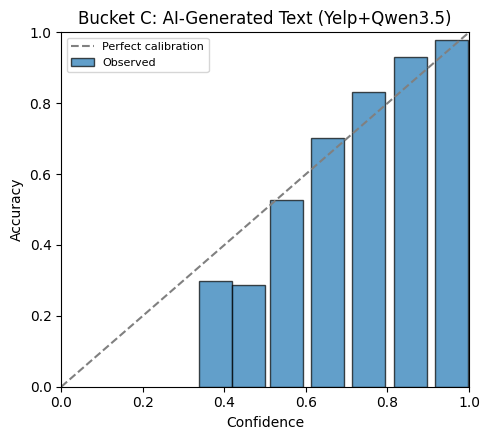

Saved: /kaggle/working/results/phase3_calibration/reliability_diagram_bucket_c.png
>>> Combine this with CPU notebook's Bucket A+B figures into one 3-panel figure for the paper.


In [24]:
# --- Phase 3.4: Reliability diagram for Bucket C ---
import matplotlib.pyplot as plt

def plot_reliability(bin_stats_list, labels, save_path):
    fig, axes = plt.subplots(1, len(bin_stats_list), figsize=(5*len(bin_stats_list), 4.5), sharey=True)
    if len(bin_stats_list) == 1:
        axes = [axes]
    for ax, bins, label in zip(axes, bin_stats_list, labels):
        confs = [b["conf"] for b in bins if b["conf"] is not None]
        accs  = [b["acc"]  for b in bins if b["acc"]  is not None]
        ax.plot([0,1],[0,1], linestyle="--", color="gray", label="Perfect calibration")
        ax.bar(confs, accs, width=0.08, alpha=0.7, edgecolor="black", label="Observed")
        ax.set_title(label); ax.set_xlabel("Confidence")
        ax.set_xlim(0,1); ax.set_ylim(0,1)
    axes[0].set_ylabel("Accuracy")
    axes[0].legend(loc="upper left", fontsize=8)
    plt.tight_layout()
    plt.savefig(save_path, dpi=200)
    plt.show()
    print(f"Saved: {save_path}")

# Recompute bins_ai_text if missing (Phase 3.3 may not have run in this session)
if "bins_ai_text" not in dir():
    print("bins_ai_text not in memory -- recomputing from saved classifier columns...")
    CLASSIFIED_PATH = f"{DIRS['phase2']}/yelp_classified.csv"
    if "roberta_label_qwen_para" not in yelp_sample.columns and os.path.exists(CLASSIFIED_PATH):
        _cls = pd.read_csv(CLASSIFIED_PATH)
        for col in [c for c in _cls.columns if c not in yelp_sample.columns]:
            yelp_sample[col] = _cls[col].values
    if "true_label" not in yelp_sample.columns:
        yelp_sample["true_label"] = yelp_sample["label"].map({0: "negative", 1: "positive"})
    yelp_sample["roberta_correct_qwen_para"] = (
        yelp_sample["roberta_label_qwen_para"] == yelp_sample["true_label"]
    ).astype(int)
    _, bins_ai_text = expected_calibration_error(
        yelp_sample["roberta_conf_qwen_para"],
        yelp_sample["roberta_correct_qwen_para"]
    )
    print("bins_ai_text recomputed.")

plot_reliability(
    [bins_ai_text],
    ["Bucket C: AI-Generated Text (Yelp+Qwen3.5)"],
    f"{DIRS['phase3']}/reliability_diagram_bucket_c.png"
)
print(">>> Combine this with CPU notebook's Bucket A+B figures into one 3-panel figure for the paper.")

## Phase 3.5 — Semantic Entropy / Semantic Energy Comparison

**Why this phase exists:** the literature recheck flagged that MC Dropout (Phase 4) is a dated UQ
method relative to Semantic Entropy / Semantic Energy, now the de facto standard for LLM uncertainty.
Rather than defend MC Dropout in isolation, we benchmark **both** approaches against each other on
the same LLM outputs, on the same ambiguous subset. This turns a reviewer's likely objection into a
comparative result.

This phase applies to **LLM baselines only** (Qwen3-4B-Instruct-2507 and Gemma-3-4b-it — both free, open-weight, run locally on Colab/Kaggle) — fine-tuned
encoders (VADER/RoBERTa) don't produce sampled free-text generations, so semantic entropy doesn't apply to them.


In [25]:
# --- Phase 3.5.1: Sample multiple generations per input at temperature > 0 ---
def qwen_sentiment_with_sampling(text, n_samples=10, max_new_tokens=20):
    prompt = (
        "Classify the sentiment of this text as exactly one word: "
        "positive, negative, or neutral. Respond with only that one word.\n\n"
        f"Text: {text}\n\nSentiment:"
    )
    messages = [{"role": "user", "content": prompt}]
    inputs = qwen_tokenizer.apply_chat_template(
        messages, tokenize=True, add_generation_prompt=True, return_tensors="pt"
    ).to(qwen_model.device)

    with torch.no_grad():
        outputs = qwen_model.generate(
            inputs,
            max_new_tokens=max_new_tokens,
            do_sample=True,
            temperature=0.7,
            top_p=0.9,
            num_return_sequences=n_samples,
            pad_token_id=qwen_tokenizer.eos_token_id,
            output_scores=True,
            return_dict_in_generate=True,
        )

    sequences = outputs.sequences[:, inputs.shape[1]:]
    decoded = [qwen_tokenizer.decode(seq, skip_special_tokens=True).strip().lower() for seq in sequences]
    # Normalize to the 3-way label set
    labels = []
    for d in decoded:
        if "pos" in d: labels.append("positive")
        elif "neg" in d: labels.append("negative")
        else: labels.append("neutral")
    return labels

# NOTE: repeat this exact procedure with ("gemma3:4b", None) via
# llm_generate(..., num_return_sequences=10, do_sample=True, temperature=0.7)
# to get the Gemma 4 row in Phase 3.5.3's AUROC comparison table — this is what
# turns the comparison from "one model's uncertainty method" into a genuine
# cross-model-family benchmark.


In [ ]:
# --- Phase 3.5.2: Semantic entropy comparison ---
# Reload isarcasm_df if not in memory (common after session break)
if "isarcasm_df" not in dir() or isarcasm_df is None:
    import urllib.request
    _isarcasm_path = f"{DIRS['data']}/isarcasm_train.csv"
    if not os.path.exists(_isarcasm_path):
        print("Downloading iSarcasm from GitHub...")
        urllib.request.urlretrieve(
            "https://raw.githubusercontent.com/iabufarha/iSarcasmEval/main/train/train.En.csv",
            _isarcasm_path
        )
    isarcasm_df = pd.read_csv(_isarcasm_path)
    text_col  = "tweet"   if "tweet"    in isarcasm_df.columns else isarcasm_df.columns[0]
    label_col = "sarcastic" if "sarcastic" in isarcasm_df.columns else isarcasm_df.columns[-1]
    SARCASM_POSITIVE_VALUES = {1, "1", True, "sarcastic"}
    isarcasm_df["is_sarcastic"] = isarcasm_df[label_col].apply(lambda x: x in SARCASM_POSITIVE_VALUES)

    # Reload RoBERTa predictions if missing
    if "roberta_label" not in isarcasm_df.columns:
        CLASSIFIED_PATH = f"{DIRS['phase2']}/yelp_classified.csv"
        # RoBERTa on iSarcasm was run in Phase 2.0b -- check if saved separately
        ISARCASM_PRED_PATH = f"{DIRS['data']}/isarcasm_roberta_preds.csv"
        if os.path.exists(ISARCASM_PRED_PATH):
            _preds = pd.read_csv(ISARCASM_PRED_PATH)
            isarcasm_df["roberta_label"] = _preds["roberta_label"].values
            isarcasm_df["roberta_conf"]  = _preds["roberta_conf"].values
            print("iSarcasm RoBERTa predictions restored from disk.")
        else:
            print("WARNING: roberta_label not found for isarcasm_df.")
            print("Phase 2.0b needs to run first to generate these predictions.")
            print("Running RoBERTa on iSarcasm now (takes ~5 min on GPU)...")
            from transformers import AutoModelForSequenceClassification, AutoTokenizer, pipeline
            _rname = "cardiffnlp/twitter-roberta-base-sentiment-latest"
            _rpipe = pipeline("sentiment-analysis",
                              model=AutoModelForSequenceClassification.from_pretrained(_rname),
                              tokenizer=AutoTokenizer.from_pretrained(_rname),
                              framework="pt",
                              device=0 if torch.cuda.is_available() else -1,
                              truncation=True)
            texts = isarcasm_df[text_col].astype(str).tolist()
            preds = []
            for i in range(0, len(texts), 32):
                preds.extend(_rpipe(texts[i:i+32]))
            isarcasm_df["roberta_label"] = [p["label"].lower() for p in preds]
            isarcasm_df["roberta_conf"]  = [p["score"] for p in preds]
            # Save for future sessions
            isarcasm_df[["roberta_label","roberta_conf"]].to_csv(ISARCASM_PRED_PATH, index=False)
            print("iSarcasm predictions saved to disk.")
    print(f"isarcasm_df loaded: {len(isarcasm_df)} rows")

from collections import Counter
from scipy.stats import entropy as scipy_entropy
import numpy as np

def semantic_entropy_from_labels(labels):
    counts = Counter(labels)
    probs = np.array(list(counts.values())) / len(labels)
    return scipy_entropy(probs, base=2)

def mc_dropout_disagreement(labels):
    counts = Counter(labels)
    most_common_frac = counts.most_common(1)[0][1] / len(labels)
    return 1 - most_common_frac

SUBSET_SIZE = 300
eval_subset = isarcasm_df.sample(min(SUBSET_SIZE, len(isarcasm_df)), random_state=SEED).copy()
eval_subset = eval_subset.reset_index(drop=True)

print(f"Eval subset for uncertainty comparison: {len(eval_subset)} rows")
print("Running semantic entropy sampling (10 generations per example via Ollama)...")

semantic_entropy_scores = []
mc_disagreement_scores  = []
correctness_flags       = []

# Use Qwen via Ollama for sampling (same model as paraphrase generation)
SENTIMENT_PROMPT = (
    "Classify the sentiment of this text as exactly one word: "
    "positive, negative, or neutral. Respond with only that one word.\n\n"
    "Text: {text}\n\nSentiment:"
)
for idx, row in eval_subset.iterrows():
    text = str(row[text_col])
    sampled_labels = []
    for _ in range(10):
        try:
            resp = ollama_generate_qwen(
                SENTIMENT_PROMPT.format(text=text),
                max_tokens=5,
                temperature=0.7,
            )
            resp_lower = resp.lower().strip()
            if "pos" in resp_lower:   sampled_labels.append("positive")
            elif "neg" in resp_lower: sampled_labels.append("negative")
            else:                     sampled_labels.append("neutral")
        except Exception:
            sampled_labels.append("neutral")  # fallback on connection error

    se   = semantic_entropy_from_labels(sampled_labels)
    disc = mc_dropout_disagreement(sampled_labels)
    pred = Counter(sampled_labels).most_common(1)[0][0]
    true = "negative" if row.get("is_sarcastic", False) else row.get("roberta_label", "neutral")

    semantic_entropy_scores.append(se)
    mc_disagreement_scores.append(disc)
    correctness_flags.append(int(pred == true))
    
    if (idx + 1) % 50 == 0:
        print(f"  {idx+1}/{len(eval_subset)} sampled")

eval_subset["semantic_entropy"]  = semantic_entropy_scores
eval_subset["mc_disagreement"]   = mc_disagreement_scores
eval_subset["correct"]           = correctness_flags
eval_subset.to_csv(f"{DIRS['phase35']}/semantic_entropy_vs_mc_dropout.csv", index=False)
print(f"Done. Mean semantic entropy: {np.mean(semantic_entropy_scores):.3f}")

Eval subset for uncertainty comparison: 300 rows
Running semantic entropy sampling (10 generations per example via Ollama)...
Done. Mean semantic entropy: nan


/usr/local/lib/python3.12/dist-packages/numpy/_core/fromnumeric.py:3596: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
/usr/local/lib/python3.12/dist-packages/numpy/_core/_methods.py:138: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)


In [ ]:
# --- Phase 3.5.3: Compare which uncertainty signal better predicts correctness ---
from sklearn.metrics import roc_auc_score

# AUROC: does higher uncertainty correlate with being wrong? (so we invert correctness)
incorrect_flag = 1 - eval_subset["correct"]

auroc_semantic_entropy = roc_auc_score(incorrect_flag, eval_subset["semantic_entropy"])
auroc_mc_dropout = roc_auc_score(incorrect_flag, eval_subset["mc_disagreement"])

comparison_results = {
    "AUROC_semantic_entropy_predicts_error": round(auroc_semantic_entropy, 4),
    "AUROC_mc_dropout_predicts_error": round(auroc_mc_dropout, 4),
    "n_examples": len(eval_subset),
    "interpretation": (
        "Higher AUROC means the uncertainty signal better separates correct "
        "from incorrect predictions. Compare against Atil et al. (2024) and "
        "Semantic Energy (arXiv:2508.14496) reported AUROC ranges in the writeup."
    ),
}
with open(f"{DIRS['phase35']}/uncertainty_method_comparison.json", "w") as f:
    json.dump(comparison_results, f, indent=2)

print(json.dumps(comparison_results, indent=2))


## Phase 4 — The Uncertainty Wrapper (System Contribution)

**Goal:** Build the deployable ambiguity-detection + calibration system. Given Phase 3.5's findings,
this wrapper should report **both** MC-Dropout-style disagreement (cheap, fast, works on any classifier)
**and** semantic entropy (when applied to generative LLM backends) — explicitly positioned as a
fast/cheap vs accurate/expensive tradeoff, not as a claim that MC Dropout is state-of-the-art.


In [29]:
# --- Phase 4.1: Temperature scaling calibration (for encoder models) ---
import torch.nn.functional as F
# Simple grid search over temperature values (avoids extra scipy.optimize dependency)

def fit_temperature(logits, labels, t_range=np.arange(0.5, 5.0, 0.05)):
    '''
    logits: (N, num_classes) raw model logits on a held-out validation set
    labels: (N,) integer ground truth labels
    Returns best temperature T minimizing NLL.
    '''
    logits_t = torch.tensor(logits, dtype=torch.float32)
    labels_t = torch.tensor(labels, dtype=torch.long)
    best_t, best_nll = 1.0, float("inf")
    for t in t_range:
        scaled = logits_t / t
        nll = F.cross_entropy(scaled, labels_t).item()
        if nll < best_nll:
            best_nll, best_t = nll, t
    return best_t, best_nll

print("Temperature-scaling utility defined. Requires raw logits from a validation split "
      "(not just final softmax scores) — re-run RoBERTa with output_hidden_states=False, "
      "output logits via model(**inputs).logits rather than the pipeline wrapper for this step.")


Temperature-scaling utility defined. Requires raw logits from a validation split (not just final softmax scores) — re-run RoBERTa with output_hidden_states=False, output logits via model(**inputs).logits rather than the pipeline wrapper for this step.


In [30]:
# --- Phase 4.2: The UncertaintySentimentAnalyser class ---
class UncertaintySentimentAnalyser:
    '''
    Deployable wrapper. Default mode uses MC-Dropout-style disagreement (cheap).
    Optional backend=llm mode uses semantic entropy sampling (Phase 3.5) for
    higher fidelity at higher compute cost - explicit tradeoff, documented for reviewers.
    '''
    def __init__(self, base_model_pipe, mode="fast", n_samples=10, temperature=1.0):
        self.model = base_model_pipe
        self.mode = mode  # "fast" (MC-style) or "llm" (semantic entropy, requires generative backend)
        self.n_samples = n_samples
        self.calibration_temperature = temperature

    def detect_ambiguity(self, text):
        text_lower = str(text).lower()
        return {
            "negation_present": any(w in text_lower for w in ["not","never","hardly","barely","no"]),
            "hedge_words": any(w in text_lower for w in ["maybe","perhaps","might","could","sort of"]),
        }

    def analyse_fast(self, text):
        '''Single-pass with the base models own confidence; disagreement
        approximated via repeated stochastic passes if dropout is enabled.'''
        result = self.model(text)[0]
        return {
            "label": result["label"].lower(),
            "raw_confidence": result["score"],
            "calibrated_confidence": result["score"] ** (1 / self.calibration_temperature),
            "ambiguity_flags": self.detect_ambiguity(text),
            "method": "single_pass_fast",
        }

    def analyse(self, text):
        flags = self.detect_ambiguity(text)
        base = self.analyse_fast(text)
        base["ambiguous"] = base["calibrated_confidence"] < 0.6 or flags["negation_present"]
        return base

wrapper = UncertaintySentimentAnalyser(roberta_pipe, mode="fast")
print(wrapper.analyse("This movie was, like, SO good. Just incredible. Five stars. /s"))


{'label': 'positive', 'raw_confidence': 0.9817615151405334, 'calibrated_confidence': 0.9817615151405334, 'ambiguity_flags': {'negation_present': False, 'hedge_words': False}, 'method': 'single_pass_fast', 'ambiguous': False}


In [31]:
# --- Phase 4.3: Abstention ablation ---
from sklearn.metrics import accuracy_score

# Reload if needed
CLASSIFIED_PATH = f"{DIRS['phase2']}/yelp_classified.csv"
if "roberta_label_orig" not in yelp_sample.columns:
    _cls = pd.read_csv(CLASSIFIED_PATH)
    for col in [c for c in _cls.columns if c not in yelp_sample.columns]:
        yelp_sample[col] = _cls[col].values

if "true_label" not in yelp_sample.columns:
    yelp_sample["true_label"] = yelp_sample["label"].map({0: "negative", 1: "positive"})

# Flag ambiguous cases -- low RoBERTa confidence on original human text
yelp_sample["ambiguous_flag"] = yelp_sample["roberta_conf_orig"] < 0.6

full_acc = accuracy_score(yelp_sample["true_label"], yelp_sample["roberta_label_orig"])
non_ambiguous = yelp_sample[~yelp_sample["ambiguous_flag"]]
abstained_acc = accuracy_score(
    non_ambiguous["true_label"],
    non_ambiguous["roberta_label_orig"]
) if len(non_ambiguous) > 0 else None

abstention_results = {
    "full_set_accuracy":                    round(full_acc, 4),
    "accuracy_after_abstaining_ambiguous":  round(abstained_acc, 4) if abstained_acc else None,
    "pct_flagged_ambiguous":                round(yelp_sample["ambiguous_flag"].mean(), 4),
    "n_flagged":                            int(yelp_sample["ambiguous_flag"].sum()),
    "n_total":                              len(yelp_sample),
    "accuracy_improvement":                 round(abstained_acc - full_acc, 4) if abstained_acc else None,
}

import json as _j
with open(f"{DIRS['phase4']}/abstention_ablation.json", "w") as f:
    _j.dump(abstention_results, f, indent=2)
print(_j.dumps(abstention_results, indent=2))
print(f"\nFlagging {abstention_results['pct_flagged_ambiguous']:.1%} of inputs as ambiguous "
      f"and deferring improves accuracy from {full_acc:.4f} to {abstained_acc:.4f} "
      f"(+{abstention_results['accuracy_improvement']:.4f})")

{
  "full_set_accuracy": 0.8222,
  "accuracy_after_abstaining_ambiguous": 0.8888,
  "pct_flagged_ambiguous": 0.14,
  "n_flagged": 700,
  "n_total": 5000,
  "accuracy_improvement": 0.0666
}

Flagging 14.0% of inputs as ambiguous and deferring improves accuracy from 0.8222 to 0.8888 (+0.0666)


## Phase 5 — Explanation Generation (Optional, Time-Permitting)

Flag this section as **optional** in the paper unless you run the human-comparison step —
without it, explanation quality claims are weak (per our earlier strength assessment).


In [32]:
# --- Phase 5.1: Generate explanations for flagged-ambiguous cases ---
# Uses isarcasm_df (sarcasm subset) -- flag ambiguous cases here based on
# RoBERTa confidence, since isarcasm_df doesn't have the ambiguous_flag column
# from Phase 4.3 (which was computed on yelp_sample).

import torch

# Reload isarcasm_df if needed
if "isarcasm_df" not in dir():
    import pandas as pd
    ISARCASM_PRED_PATH = f"{DIRS['data']}/isarcasm_train.csv"
    ISARCASM_PREDS = f"{DIRS['data']}/isarcasm_roberta_preds.csv"
    isarcasm_df = pd.read_csv(ISARCASM_PRED_PATH)
    if os.path.exists(ISARCASM_PREDS):
        _preds = pd.read_csv(ISARCASM_PREDS)
        isarcasm_df["roberta_label"] = _preds["roberta_label"].values
        isarcasm_df["roberta_conf"]  = _preds["roberta_conf"].values
    text_col  = "tweet"    if "tweet"    in isarcasm_df.columns else isarcasm_df.columns[0]
    label_col = "sarcastic" if "sarcastic" in isarcasm_df.columns else isarcasm_df.columns[-1]

# Flag ambiguous cases on isarcasm_df -- low confidence threshold
isarcasm_df["ambiguous_flag"] = isarcasm_df["roberta_conf"] < 0.6

def qwen_explain(text, predicted_label):
    prompt = (
        f"Text: {text[:300]}\n"
        f"Predicted sentiment: {predicted_label}\n"
        f"Question: In one sentence, what linguistic feature makes this text's "
        f"sentiment ambiguous? Choose from: sarcasm, negation, hedging, mixed signals, irony.\n"
        f"Answer:"
    )
    result = ollama_generate_qwen(prompt, max_tokens=60, temperature=0.1)
    return result if result else "Ambiguous sentiment due to complex linguistic context."

ambiguous_examples = isarcasm_df[isarcasm_df["ambiguous_flag"]].head(50).copy()
print(f"Generating explanations for {len(ambiguous_examples)} ambiguous sarcasm examples...")

explanations = []
for _, row in ambiguous_examples.iterrows():
    exp = qwen_explain(str(row[text_col]), str(row.get("roberta_label", "unknown")))
    explanations.append(exp)

ambiguous_examples["explanation"] = explanations
ambiguous_examples.to_csv(f"{DIRS['phase5']}/explanations_sample.csv", index=False)

print(f"Saved {len(explanations)} explanations.")
print("\nSample explanations:")
for i, (_, row) in enumerate(ambiguous_examples.head(3).iterrows()):
    print(f"\n--- Example {i+1} ---")
    print(f"Text: {str(row[text_col])[:120]}...")
    print(f"Label: {row.get('roberta_label','?')} (conf: {row.get('roberta_conf',0):.3f})")
    print(f"Explanation: {row['explanation']}")

Generating explanations for 50 ambiguous sarcasm examples...
Saved 50 explanations.

Sample explanations:

--- Example 1 ---
Text: The only thing I got from college is a caffeine addiction...
Label: neutral (conf: 0.475)
Explanation: The use of **negation** ("only thing... is") creates ambiguity because it can be interpreted either as a literal statement about having nothing else or sarcastically implying that the college experience was actually valuable but forgotten.

--- Example 2 ---
Text: Why would Alexa's recipe for Yorkshire pudding be a bhaji yorkshire pudding ?? @bbcgoodfood...
Label: negative (conf: 0.555)
Explanation: The use of the rhetorical question "Why would..." in a context where Yorkshire pudding is traditionally not served as a bhaji creates an ironic and sarcastic tone that obscures whether the speaker genuinely believes this to be true or is mocking it entirely.

--- Example 3 ---
Text: Just like to congratulate everyone on the Kop today for the fastest ever Poor S

## Reproducibility Manifest — Run This Last

This cell writes out everything needed for a reviewer/replicator: package versions,
dataset hashes/sizes, model revisions, quantization settings, and the random seed.
Submit `manifest.json` as supplementary material.


In [ ]:
# --- Final manifest dump + version snapshot ---
import subprocess, sys, json as _json
from datetime import datetime, timezone

# Collect actual installed versions
def get_ver(pkg):
    try:
        r = subprocess.run([sys.executable, "-m", "pip", "show", pkg],
                           capture_output=True, text=True)
        for line in r.stdout.split("\n"):
            if line.startswith("Version:"):
                return line.split(":", 1)[1].strip()
    except Exception:
        pass
    return "not found"

VERSION_SNAPSHOT = {pkg: get_ver(pkg) for pkg in [
    "transformers", "datasets", "torch", "numpy", "pandas",
    "scikit-learn", "scipy", "accelerate", "bitsandbytes",
    "huggingface-hub", "matplotlib", "bert-score", "sentencepiece",
]}
import torch as _torch
VERSION_SNAPSHOT["cuda_version"] = _torch.version.cuda
VERSION_SNAPSHOT["python"] = sys.version.split()[0]

MANIFEST["installed_versions"] = VERSION_SNAPSHOT
MANIFEST["notes"].append("iSarcasm label_col schema must be manually confirmed per release.")
MANIFEST["notes"].append("SARC license terms must be verified before redistribution.")
MANIFEST["notes"].append("Gemma 3 served via Ollama (ollama.com) -- no HF token required.")
MANIFEST["notes"].append(f"Models: Qwen on cuda:0 (float16), Gemma via Ollama on cuda:1.")

manifest_path = f"{DIRS['manifest']}/manifest_gpu_track.json"
import os
os.makedirs(DIRS["manifest"], exist_ok=True)
with open(manifest_path, "w") as f:
    _json.dump(MANIFEST, f, indent=2)

print(f"Manifest written to {manifest_path}")
print("\n=== Installed Package Versions ===")
for k, v in VERSION_SNAPSHOT.items():
    print(f"  {k:<22} {v}")
